In [ ]:
!pip install datasets transformers rank_bm25 pandas numpy matplotlib -q

In [ ]:
import torch
import torch.nn.functional as F
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
print("All imports successful")

All imports successful


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
passages = [
    "Hot Tub Time Machine was filmed at Fernie Alpine Resort in British Columbia.",
    "The Eiffel Tower is located in Paris, France.",
    "The capital of Japan is Tokyo.",
    "The movie Titanic was directed by James Cameron.",
    "Mount Everest is the tallest mountain in the world.",
    "Python is a popular programming language for machine learning.",
    "The Great Wall of China being visible from space is a myth.",
    "The Amazon rainforest is located in South America.",
    "The speed of light is approximately 3 x 10^8 meters per second.",
    "The Pacific Ocean is the largest ocean on Earth.",
    "The capital of Canada is Ottawa.",
    "The Nile is the longest river in Africa.",
    "The chemical symbol for gold is Au.",
    "The moon orbits the Earth.",
    "The tallest animal on Earth is the giraffe.",
    "The capital of Australia is Canberra.",
    "Water freezes at 0 degrees Celsius.",
    "The human heart has four chambers.",
    "The largest planet in the solar system is Jupiter.",
    "The currency of the United Kingdom is the pound sterling.",
    "The Statue of Liberty is in New York Harbor.",
    "Shakespeare wrote Hamlet.",
    "The boiling point of water is 100 degrees Celsius at sea level.",
    "The capital of Germany is Berlin.",
    "The Sahara is the largest hot desert in the world."
]

eval_data = [
    {"question": "Where was Hot Tub Time Machine filmed?",          "gold_answer": "Fernie Alpine Resort"},
    {"question": "Where is the Eiffel Tower located?",              "gold_answer": "Paris, France"},
    {"question": "What is the capital of Japan?",                   "gold_answer": "Tokyo"},
    {"question": "Who directed the movie Titanic?",                 "gold_answer": "James Cameron"},
    {"question": "Where is the Amazon rainforest located?",         "gold_answer": "South America"},
    {"question": "What is the capital of Canada?",                  "gold_answer": "Ottawa"},
    {"question": "What is the longest river in Africa?",            "gold_answer": "Nile"},
    {"question": "What is the chemical symbol for gold?",           "gold_answer": "Au"},
    {"question": "What does the moon orbit?",                       "gold_answer": "Earth"},
    {"question": "What is the tallest animal on Earth?",            "gold_answer": "giraffe"},
    {"question": "What is the capital of Australia?",               "gold_answer": "Canberra"},
    {"question": "At what temperature does water freeze?",          "gold_answer": "0 degrees Celsius"},
    {"question": "How many chambers does the human heart have?",    "gold_answer": "four"},
    {"question": "What is the largest planet in the solar system?", "gold_answer": "Jupiter"},
    {"question": "What is the currency of the United Kingdom?",     "gold_answer": "pound sterling"},
    {"question": "Where is the Statue of Liberty?",                 "gold_answer": "New York Harbor"},
    {"question": "Who wrote Hamlet?",                               "gold_answer": "Shakespeare"},
    {"question": "At what temperature does water boil at sea level?","gold_answer": "100 degrees Celsius"},
    {"question": "What is the capital of Germany?",                 "gold_answer": "Berlin"},
    {"question": "What is the largest hot desert in the world?",    "gold_answer": "Sahara"},
]

print(f"Toy corpus: {len(passages)} passages, {len(eval_data)} eval questions")

Toy corpus: 25 passages, 20 eval questions


In [ ]:
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s,]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def exact_match(prediction, gold):
    return normalize_text(prediction) == normalize_text(gold)

def contains_gold(prediction, gold):
    return normalize_text(gold) in normalize_text(prediction)

def contains_gold_aliases(prediction, aliases):
    pred_norm = normalize_text(prediction)
    return any(normalize_text(alias) in pred_norm for alias in aliases)

def exact_match_aliases(prediction, aliases):
    pred_norm = normalize_text(prediction)
    return any(pred_norm == normalize_text(alias) for alias in aliases)

def clean_prediction(text):
    text = text.strip()
    text = re.sub(r"^\(?[ivxlcdm]+\)?[\.\):]?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^\d+[\.\):]?\s*", "", text)
    text = re.sub(r"^(the answer is|answer:)\s*", "", text.lower())
    return text.strip(" -\n\t:;,.")

def truncate_passage(passage, max_words=45):
    words = passage.split()
    if len(words) <= max_words:
        return passage
    return " ".join(words[:max_words]) + "..."

def build_rag_prompt(question, retrieved_passages, max_words_per_passage=45):
    truncated = [truncate_passage(p, max_words=max_words_per_passage)
                 for p in retrieved_passages]
    context = "\n\n".join(
        [f"Passage {i+1}: {p}" for i, p in enumerate(truncated)]
    )
    prompt = (
        "You are given multiple passages.\n"
        "One of them contains the answer.\n\n"
        "Step 1: Identify the passage that answers the question.\n"
        "Step 2: Extract the answer from that passage.\n\n"
        "Return ONLY the final answer phrase.\n\n"
        f"{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )
    return prompt

def get_generation_passages(retrieved, mode):
    if mode == "top1":
        return [retrieved[0]]
    elif mode == "full_topk":
        return retrieved
    raise ValueError(f"Unknown mode: {mode}")

def run_adaptive_stopping(conf_df, threshold):
    """
    For each question, iterate over k in ascending order.
    Stop when confidence gain from k-1 to k drops below threshold.
    Returns a dataframe with one row per question.
    """
    rows = []
    full_topk_df = conf_df[conf_df["generation_mode"] == "full_topk"]
    for question, group in full_topk_df.groupby("question"):
        group = group.sort_values("k").reset_index(drop=True)
        chosen_row = group.iloc[-1] # default is using largest k
        for i in range(1, len(group)):
            gain = group.loc[i, "confidence"] - group.loc[i-1, "confidence"]
            if gain < threshold:
                chosen_row = group.loc[i-1]
                break
        rows.append({
            "question":      chosen_row["question"],
            "gold_answer":   chosen_row["gold_answer"],
            "chosen_k":      chosen_row["k"],
            "prediction":    chosen_row["prediction"],
            "confidence":    chosen_row["confidence"],
            "exact_match":   chosen_row["exact_match"],
            "contains_gold": chosen_row["contains_gold"],
            "threshold":     threshold
        })
    return pd.DataFrame(rows)

print("Utility functions defined.")

Utility functions defined.


In [ ]:
def generate_answer(prompt, tokenizer, model, max_new_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return clean_prediction(answer)

def generate_answer_and_confidence(prompt, tokenizer, model, max_new_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=512).to(device)
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )
    generated_text = tokenizer.decode(
        generated_ids[0], skip_special_tokens=True
    ).strip()
    pred_clean = clean_prediction(generated_text)

    if generated_ids.shape[1] == 0:
        return pred_clean, -999.0

    # Correct confidence scoring for encoder-decoder (T5):
    # shift_right produces the decoder_input_ids T5 expects
    decoder_input_ids = model._shift_right(generated_ids)
    with torch.no_grad():
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            decoder_input_ids=decoder_input_ids
        )
    logits = outputs.logits  # [1, answer_len, vocab_size]
    log_probs = F.log_softmax(logits, dim=-1)

    answer_log_probs = []
    for t in range(generated_ids.shape[1]):
        token_id = generated_ids[0, t].item()
        lp = log_probs[0, t, token_id].item()
        answer_log_probs.append(lp)

    avg_log_prob = sum(answer_log_probs) / len(answer_log_probs)
    return pred_clean, avg_log_prob

print("Generation functions defined.")

Generation functions defined.


In [ ]:
tokenized_passages = [p.lower().split() for p in passages]
toy_bm25 = BM25Okapi(tokenized_passages)

def retrieve_top_k_toy(query, k=3):
    tokenized_query = query.lower().split()
    scores = toy_bm25.get_scores(tokenized_query)
    top_k_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k]
    return [passages[i] for i in top_k_indices]

print("Toy BM25 index built.")
print("Running toy corpus pilot with flan-t5-small (positive control)...")

# Load small model just for pilot
toy_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-small")
toy_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small").to(device)
toy_model.eval()

toy_results = []
for item in eval_data:
    q, gold = item["question"], item["gold_answer"]
    for k in [1, 2, 3, 5]:
        retrieved = retrieve_top_k_toy(q, k=k)
        prompt = build_rag_prompt(q, retrieved)
        pred, conf = generate_answer_and_confidence(prompt, toy_tokenizer, toy_model)
        toy_results.append({
            "k": k,
            "prediction": pred,
            "confidence": conf,
            "contains_gold": contains_gold(pred, gold),
        })

toy_df = pd.DataFrame(toy_results)
toy_summary = toy_df.groupby("k")[["contains_gold", "confidence"]].mean().round(4)
print("\nToy corpus pilot results (positive control):")
print(toy_summary)
print("\nInterpretation: Flat confidence across k = noise-free context produces no marginal gain.")
print("This validates the pipeline before scaling to SQuAD/TriviaQA.")

# Free toy model from memory
del toy_model
import gc; gc.collect()
print("\nToy model freed from memory.")

Toy BM25 index built.
Running toy corpus pilot with flan-t5-small (positive control)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



Toy corpus pilot results (positive control):
   contains_gold  confidence
k                           
1           0.70    -10.0122
2           0.75     -9.9998
3           0.70    -10.0352
5           0.70    -10.0334

Interpretation: Flat confidence across k = noise-free context produces no marginal gain.
This validates the pipeline before scaling to SQuAD/TriviaQA.

Toy model freed from memory.


In [ ]:
# SQuAD
squad_dataset = load_dataset("squad", split="validation[:2000]")
squad_eval_data = []
squad_passages = []
seen_contexts = set()
for item in squad_dataset:
    context = item["context"]
    if context in seen_contexts:
        continue
    answers = item["answers"]["text"]
    if len(answers) == 0:
        continue
    seen_contexts.add(context)
    squad_eval_data.append({
        "question": item["question"],
        "gold_answer": answers[0],
        "supporting_passage": context
    })
    squad_passages.append(context)
    if len(squad_eval_data) >= 100:
        break

print(f"SQuAD eval examples: {len(squad_eval_data)}, unique passages: {len(squad_passages)}")

#TriviaQA
trivia_dataset = load_dataset("trivia_qa", "rc.wikipedia", split="validation")
trivia_eval_data = []
trivia_passages = []
seen_trivia_contexts = set()
for item in trivia_dataset:
    entity_pages = item.get("entity_pages", {})
    wiki_contexts = entity_pages.get("wiki_context", [])
    supporting_passage = None
    for ctx in wiki_contexts:
        ctx = ctx.strip()
        if ctx and ctx not in seen_trivia_contexts:
            supporting_passage = ctx
            break
    if supporting_passage is None:
        continue
    answers = item["answer"]
    gold = answers.get("value", "").strip()
    if not gold:
        continue
    seen_trivia_contexts.add(supporting_passage)
    trivia_eval_data.append({
        "question": item["question"],
        "gold_answer": gold,
        "all_aliases": [gold] + answers.get("aliases", []),
        "supporting_passage": supporting_passage
    })
    trivia_passages.append(supporting_passage)
    if len(trivia_eval_data) >= 100:
        break

print(f"TriviaQA eval examples: {len(trivia_eval_data)}, unique passages: {len(trivia_passages)}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

...

rc.wikipedia/test-00000-of-00001.parquet:   0%|          | 0.00/221M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61888 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7993 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7701 [00:00<?, ? examples/s]

TriviaQA eval examples: 100, unique passages: 100


In [ ]:
toy_distractors = [
    "The Eiffel Tower is located in Paris, France.",
    "The capital of Japan is Tokyo.",
    "The movie Titanic was directed by James Cameron.",
    "Python is a popular programming language for machine learning.",
    "The Amazon rainforest is located in South America.",
    "The Nile is the longest river in Africa.",
    "The chemical symbol for gold is Au.",
    "The moon orbits the Earth.",
    "The largest planet in the solar system is Jupiter.",
    "The Sahara is the largest hot desert in the world."
]

# SQuAD corpus: 100 passages + 10 distractors = 110
squad_retrieval_corpus = squad_passages + toy_distractors
tokenized_squad = [p.lower().split() for p in squad_retrieval_corpus]
squad_bm25 = BM25Okapi(tokenized_squad)

# TriviaQA corpus: 100 passages + 10 distractors = 110
trivia_retrieval_corpus = trivia_passages + toy_distractors
tokenized_trivia = [p.lower().split() for p in trivia_retrieval_corpus]
trivia_bm25 = BM25Okapi(tokenized_trivia)

def retrieve_top_k_squad(query, k=3):
    scores = squad_bm25.get_scores(query.lower().split())
    top_k = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k]
    return [squad_retrieval_corpus[i] for i in top_k]

def retrieve_top_k_trivia(query, k=3):
    scores = trivia_bm25.get_scores(query.lower().split())
    top_k = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k]
    return [trivia_retrieval_corpus[i] for i in top_k]

print(f"SQuAD corpus size: {len(squad_retrieval_corpus)}")
print(f"TriviaQA corpus size: {len(trivia_retrieval_corpus)}")

# Retrieval recall check
k_values = [1, 2, 3, 5]
thresholds = [-0.05, -0.02, 0.00, 0.01, 0.03, 0.05, 0.10]
lambdas = [0.0, 0.25, 0.5, 1.0]

for dataset_name, eval_data_ref, retrieve_fn in [
    ("SQuAD", squad_eval_data, retrieve_top_k_squad),
    ("TriviaQA", trivia_eval_data, retrieve_top_k_trivia),
]:
    found = {1: 0, 3: 0, 5: 0}
    for item in eval_data_ref:
        q = item["question"]
        aliases = item.get("all_aliases", [item["gold_answer"]])
        for k in [1, 3, 5]:
            if any(contains_gold_aliases(p, aliases) for p in retrieve_fn(q, k=k)):
                found[k] += 1
    n = len(eval_data_ref)
    print(f"\n{dataset_name} recall: @1={found[1]/n:.2f}, @3={found[3]/n:.2f}, @5={found[5]/n:.2f}")

SQuAD corpus size: 110
TriviaQA corpus size: 110

SQuAD recall: @1=0.74, @3=0.89, @5=0.94

TriviaQA recall: @1=0.84, @3=0.88, @5=0.90


In [ ]:
def run_full_evaluation(model_name, model_label):
    print(f"\n{'='*65}")
    print(f"EVALUATING: {model_label} ({model_name})")
    print(f"{'='*65}")

    # Aggressive memory clearing before loading model
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Memory cleared. Loading model")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    model.eval()
    print(f"Model loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}")

    all_results = {}

    for dataset_name, eval_data_ref, retrieve_fn, alias_mode in [
        ("SQuAD",    squad_eval_data,  retrieve_top_k_squad,  False),
        ("TriviaQA", trivia_eval_data, retrieve_top_k_trivia, True),
    ]:
        print(f"\n--- {dataset_name} ---")

        #Fixed-k + confidence loop
        confidence_results = []
        for q_idx, item in enumerate(eval_data_ref):
            q    = item["question"]
            gold = item["gold_answer"]
            aliases = item.get("all_aliases", [gold])
            # Periodic cache clearing every 10 questions to prevent memory buildup
            if q_idx % 10 == 0:
                gc.collect()
                torch.cuda.empty_cache()
                if q_idx > 0:
                    print(f"    [cache cleared at q={q_idx}]")
            for k in k_values:
                retrieved = retrieve_fn(q, k=k)
                for mode in ["top1", "full_topk"]:
                    gen_passages = get_generation_passages(retrieved, mode)
                    prompt = build_rag_prompt(q, gen_passages)
                    pred, conf = generate_answer_and_confidence(
                        prompt, tokenizer, model
                    )
                    if alias_mode:
                        em  = exact_match_aliases(pred, aliases)
                        cg  = contains_gold_aliases(pred, aliases)
                    else:
                        em  = exact_match(pred, gold)
                        cg  = contains_gold(pred, gold)
                    confidence_results.append({
                        "question": q, "gold_answer": gold,
                        "k": k, "generation_mode": mode,
                        "prediction": pred, "confidence": conf,
                        "exact_match": em, "contains_gold": cg,
                    })

        conf_df = pd.DataFrame(confidence_results)

        # Fixed-k summary
        fixed_summary = (
            conf_df[conf_df["generation_mode"] == "full_topk"]
            .groupby("k")[["exact_match", "contains_gold"]]
            .mean().reset_index().round(3)
        )
        print(f"\nFixed-k results (full_topk):")
        print(fixed_summary.to_string(index=False))

        # Confidence summary
        conf_summary = (
            conf_df.groupby(["generation_mode", "k"])[["confidence"]]
            .mean().reset_index().round(4)
        )
        print(f"\nConfidence signal (full_topk):")
        ft = conf_summary[conf_summary["generation_mode"] == "full_topk"]
        print(ft[["k", "confidence"]].to_string(index=False))

        # Noise analysis
        noise_results = []
        for item in eval_data_ref:
            q = item["question"]
            aliases = item.get("all_aliases", [item["gold_answer"]])
            for k in k_values:
                retrieved = retrieve_fn(q, k=k)
                relevant = sum(contains_gold_aliases(p, aliases) for p in retrieved)
                noise = k - relevant
                noise_results.append({
                    "k": k,
                    "retrieval_success": relevant > 0,
                    "relevant_count": relevant,
                    "noise_count": noise,
                    "noise_rate": noise / k
                })
        noise_df = pd.DataFrame(noise_results)
        noise_summary = (
            noise_df.groupby("k")[["retrieval_success","noise_rate"]]
            .mean().reset_index().round(3)
        )
        print(f"\nNoise analysis:")
        print(noise_summary.to_string(index=False))

        # Adaptive threshold sweep
        threshold_rows = []
        for tau in thresholds:
            df = run_adaptive_stopping(conf_df, tau)
            threshold_rows.append({
                "threshold":     tau,
                "avg_k":         round(df["chosen_k"].mean(), 3),
                "exact_match":   round(df["exact_match"].mean(), 3),
                "contains_gold": round(df["contains_gold"].mean(), 3),
            })
        adaptive_summary = pd.DataFrame(threshold_rows)
        print(f"\nAdaptive threshold sweep:")
        print(adaptive_summary.to_string(index=False))

        best_tau = adaptive_summary.sort_values(
            by=["contains_gold", "avg_k"], ascending=[False, True]
        ).iloc[0]["threshold"]
        print(f"Best τ = {best_tau}")

        best_adaptive_df = run_adaptive_stopping(conf_df, best_tau)

        k_dist = best_adaptive_df["chosen_k"].value_counts().sort_index()
        print(f"Adaptive k distribution:\n{k_dist.to_string()}")

        # Cost-aware objective
        fixed_for_obj = (
            conf_df[conf_df["generation_mode"] == "full_topk"]
            .groupby("k")[["exact_match", "contains_gold"]]
            .mean().reset_index().round(3)
        )
        fixed_for_obj["method"] = fixed_for_obj["k"].apply(lambda x: f"Fixed k={int(x)}")
        fixed_for_obj["avg_k"]  = fixed_for_obj["k"]

        adaptive_row = pd.DataFrame([{
            "method":        f"Adaptive (τ={best_tau})",
            "avg_k":         round(best_adaptive_df["chosen_k"].mean(), 3),
            "exact_match":   round(best_adaptive_df["exact_match"].mean(), 3),
            "contains_gold": round(best_adaptive_df["contains_gold"].mean(), 3),
        }])

        comparison_df = pd.concat(
            [fixed_for_obj[["method","avg_k","exact_match","contains_gold"]], adaptive_row],
            ignore_index=True
        )

        objective_df = comparison_df.copy()
        objective_df["error"] = (1 - objective_df["contains_gold"]).round(3)
        objective_df["cost"]  = (objective_df["avg_k"] / max(k_values)).round(3)
        for lam in lambdas:
            objective_df[f"L(λ={lam})"] = (
                objective_df["error"] + lam * objective_df["cost"]
            ).round(3)

        print(f"\nCost-aware objective L = E + λC:")
        print(objective_df[["method","avg_k","contains_gold","error","cost",
                             "L(λ=0.0)","L(λ=0.25)","L(λ=0.5)","L(λ=1.0)"]].to_string(index=False))

        all_results[dataset_name] = {
            "conf_df":         conf_df,
            "conf_summary":    conf_summary,
            "noise_summary":   noise_summary,
            "adaptive_summary":adaptive_summary,
            "best_tau":        best_tau,
            "best_adaptive_df":best_adaptive_df,
            "k_dist":          k_dist,
            "objective_df":    objective_df,
        }

    # Free model memory before next model
    del model, tokenizer
    import gc; gc.collect()
    print(f"\nModel {model_label} freed from memory.")

    return all_results

In [ ]:
model_configs = [
    ("google/flan-t5-small", "flan-t5-small"),
    ("google/flan-t5-base",  "flan-t5-base"),
]

all_model_results = {}
for model_name, model_label in model_configs:
    all_model_results[model_label] = run_full_evaluation(model_name, model_label)

print("\n" + "="*65)
print("ALL EVALUATIONS COMPLETE")
print("="*65)


EVALUATING: flan-t5-small (google/flan-t5-small)
Memory cleared. Loading model...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded. Parameters: 76,961,152

--- SQuAD ---
    [cache cleared at q=10]
    [cache cleared at q=20]
    [cache cleared at q=30]
    [cache cleared at q=40]
    [cache cleared at q=50]
    [cache cleared at q=60]
    [cache cleared at q=70]
    [cache cleared at q=80]
    [cache cleared at q=90]

Fixed-k results (full_topk):
 k  exact_match  contains_gold
 1         0.30           0.32
 2         0.24           0.28
 3         0.24           0.27
 5         0.22           0.25

Confidence signal (full_topk):
 k  confidence
 1     -9.9543
 2    -10.0071
 3    -10.0240
 5    -10.0360

Noise analysis:
 k  retrieval_success  noise_rate
 1               0.74       0.260
 2               0.84       0.525
 3               0.89       0.643
 5               0.94       0.744

Adaptive threshold sweep:
 threshold  avg_k  exact_match  contains_gold
     -0.05   3.61         0.27           0.32
     -0.02   2.84         0.30           0.35
      0.00   1.61         0.30           0.34
      

config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded. Parameters: 247,577,856

--- SQuAD ---
    [cache cleared at q=10]
    [cache cleared at q=20]
    [cache cleared at q=30]
    [cache cleared at q=40]
    [cache cleared at q=50]
    [cache cleared at q=60]
    [cache cleared at q=70]
    [cache cleared at q=80]
    [cache cleared at q=90]

Fixed-k results (full_topk):
 k  exact_match  contains_gold
 1         0.31           0.40
 2         0.35           0.46
 3         0.33           0.44
 5         0.32           0.44

Confidence signal (full_topk):
 k  confidence
 1     -9.8949
 2     -9.8992
 3     -9.9136
 5     -9.9155

Noise analysis:
 k  retrieval_success  noise_rate
 1               0.74       0.260
 2               0.84       0.525
 3               0.89       0.643
 5               0.94       0.744

Adaptive threshold sweep:
 threshold  avg_k  exact_match  contains_gold
     -0.05   4.29         0.32           0.45
     -0.02   3.91         0.33           0.46
      0.00   1.60         0.34           0.46
     

In [ ]:
print("\n" + "="*65)
print("CROSS-MODEL COMPARISON SUMMARY")
print("="*65)

cross_model_rows = []
for model_label, dataset_results in all_model_results.items():
    for dataset_name, res in dataset_results.items():
        obj = res["objective_df"]
        fixed_k1_cg = float(obj[obj["method"] == "Fixed k=1"]["contains_gold"].values[0])
        adap_row     = obj[~obj["method"].str.startswith("Fixed")].iloc[0]
        cross_model_rows.append({
            "Model":           model_label,
            "Dataset":         dataset_name,
            "Fixed k=1 CG":   fixed_k1_cg,
            "Adaptive CG":    adap_row["contains_gold"],
            "Best τ":          res["best_tau"],
            "avg_k (adaptive)":adap_row["avg_k"],
            "CG Gain":         round(adap_row["contains_gold"] - fixed_k1_cg, 3),
            "Cost Reduction":  round(1 - adap_row["cost"] / 0.2, 3),  # relative to fixed k=1 cost
        })

cross_df = pd.DataFrame(cross_model_rows)
print(cross_df.to_string(index=False))


CROSS-MODEL COMPARISON SUMMARY
        Model  Dataset  Fixed k=1 CG  Adaptive CG  Best τ  avg_k (adaptive)  CG Gain  Cost Reduction
flan-t5-small    SQuAD          0.32         0.35    0.03              1.19     0.03           -0.19
flan-t5-small TriviaQA          0.18         0.19    0.10              1.24     0.01           -0.24
 flan-t5-base    SQuAD          0.40         0.46    0.00              1.60     0.06           -0.60
 flan-t5-base TriviaQA          0.24         0.22    0.10              1.21    -0.02           -0.21


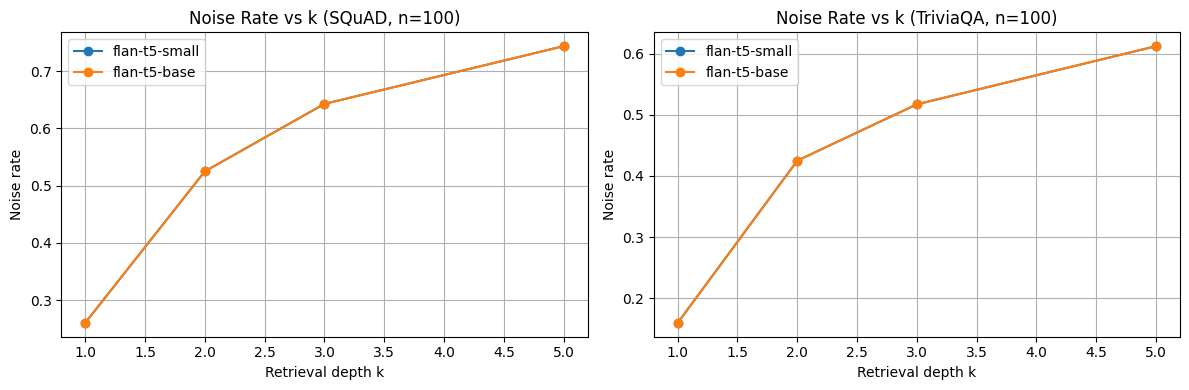

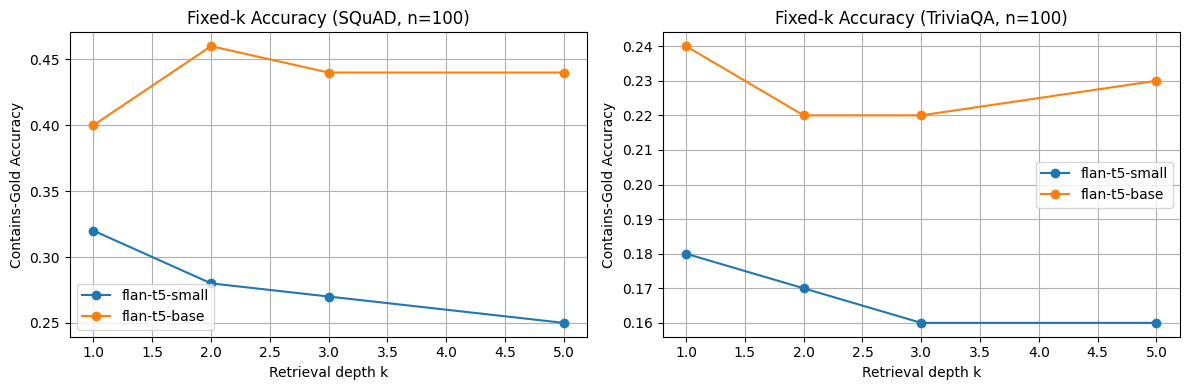

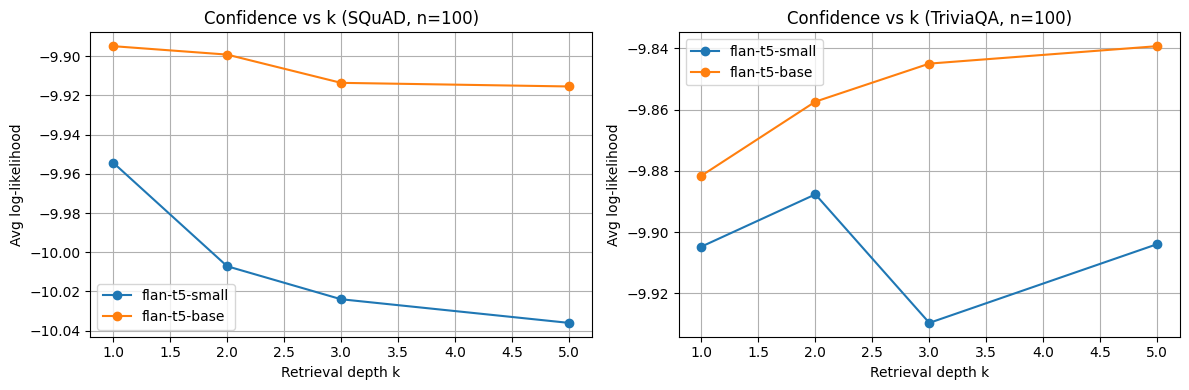

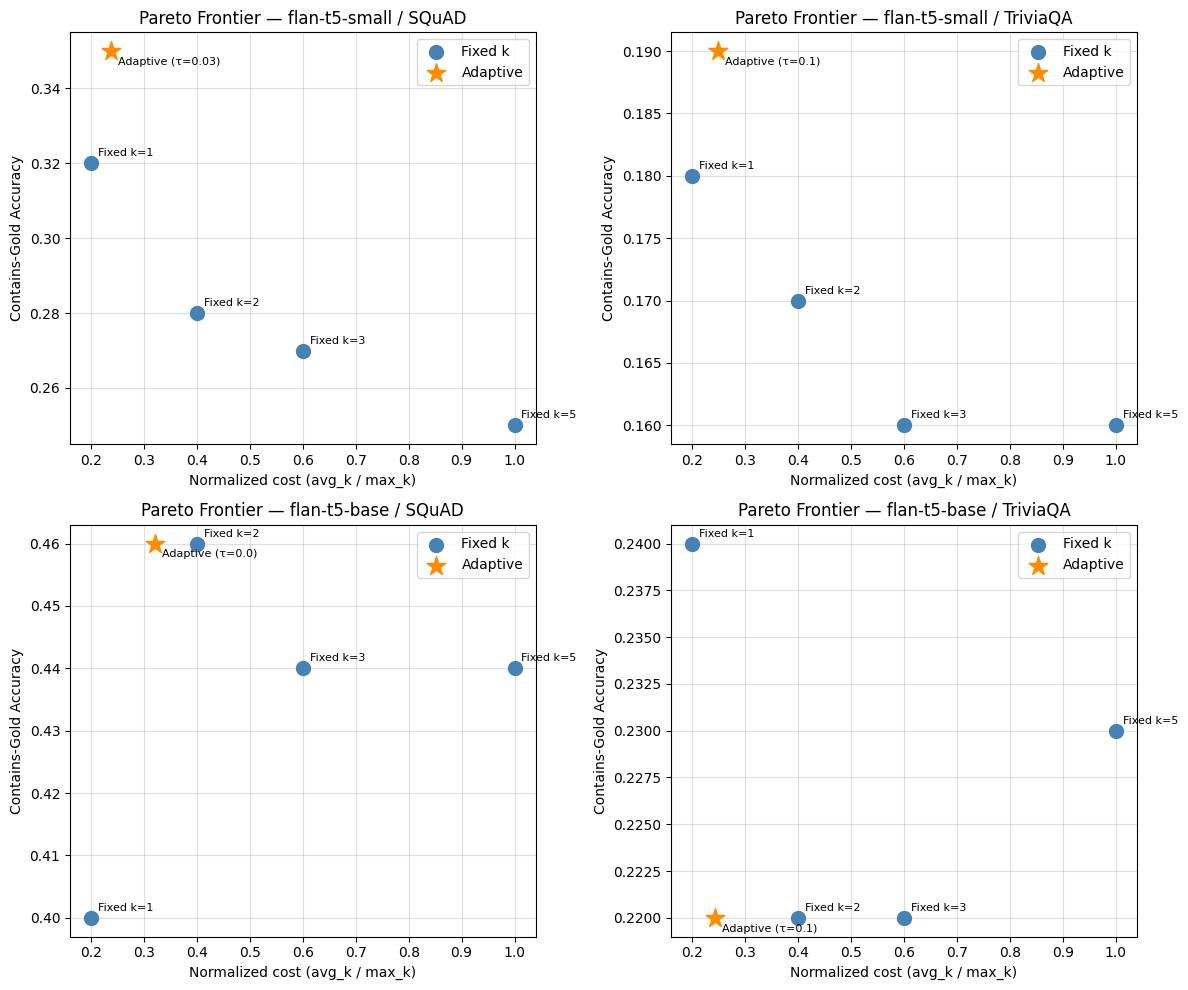

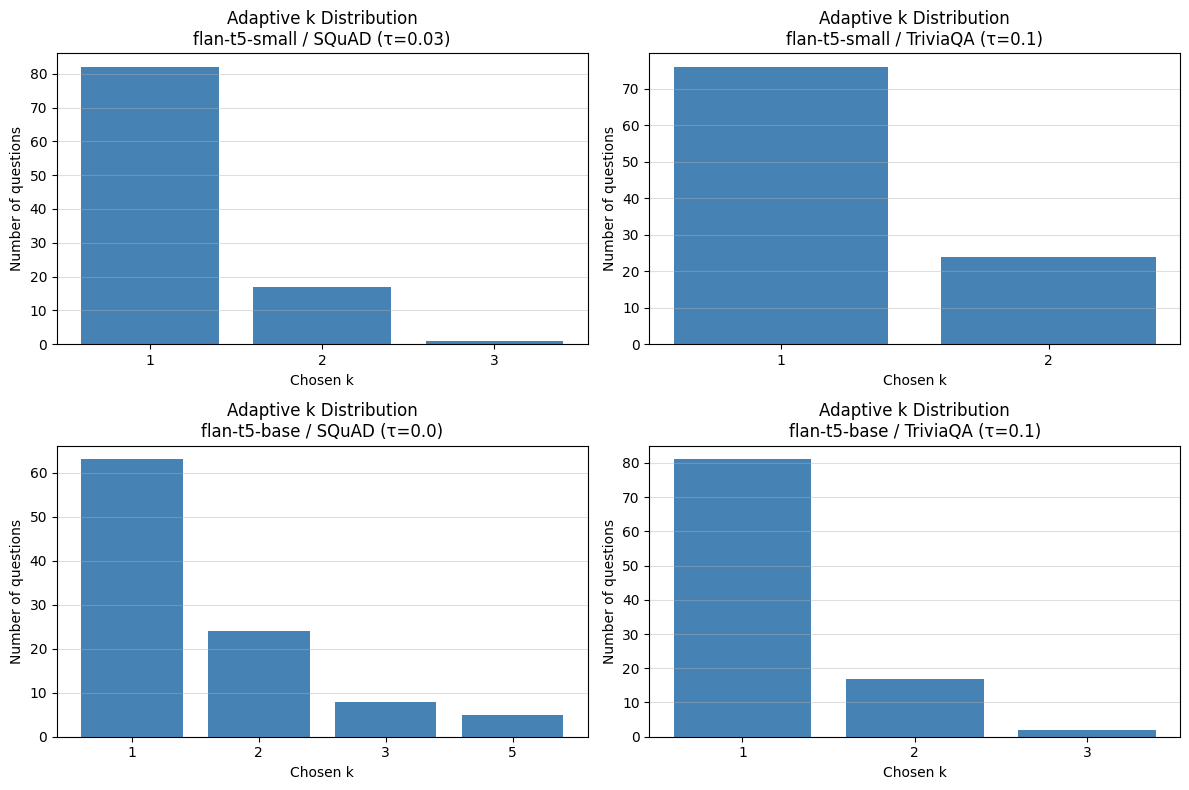

All plots saved.


In [ ]:
fig_configs = []
for model_label, dataset_results in all_model_results.items():
    for dataset_name, res in dataset_results.items():
        fig_configs.append((model_label, dataset_name, res))

# Plot 1: Noise rate vs k (both datasets, both models)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dataset_name in zip(axes, ["SQuAD", "TriviaQA"]):
    for model_label in all_model_results:
        noise = all_model_results[model_label][dataset_name]["noise_summary"]
        ax.plot(noise["k"], noise["noise_rate"], marker="o", label=model_label)
    ax.set_title(f"Noise Rate vs k ({dataset_name}, n=100)")
    ax.set_xlabel("Retrieval depth k")
    ax.set_ylabel("Noise rate")
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig("noise_rate_comparison.png", dpi=150)
plt.show()

# Plot 2: Fixed-k accuracy vs k
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dataset_name in zip(axes, ["SQuAD", "TriviaQA"]):
    for model_label in all_model_results:
        conf_df = all_model_results[model_label][dataset_name]["conf_df"]
        ft = conf_df[conf_df["generation_mode"] == "full_topk"]
        summary = ft.groupby("k")["contains_gold"].mean()
        ax.plot(summary.index, summary.values, marker="o", label=model_label)
    ax.set_title(f"Fixed-k Accuracy ({dataset_name}, n=100)")
    ax.set_xlabel("Retrieval depth k")
    ax.set_ylabel("Contains-Gold Accuracy")
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig("fixed_k_accuracy_comparison.png", dpi=150)
plt.show()

# Plot 3: Confidence vs k
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dataset_name in zip(axes, ["SQuAD", "TriviaQA"]):
    for model_label in all_model_results:
        conf_df = all_model_results[model_label][dataset_name]["conf_df"]
        ft = conf_df[conf_df["generation_mode"] == "full_topk"]
        summary = ft.groupby("k")["confidence"].mean()
        ax.plot(summary.index, summary.values, marker="o", label=model_label)
    ax.set_title(f"Confidence vs k ({dataset_name}, n=100)")
    ax.set_xlabel("Retrieval depth k")
    ax.set_ylabel("Avg log-likelihood")
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.savefig("confidence_comparison.png", dpi=150)
plt.show()

# Plot 4: Pareto frontier per model per dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for row_idx, model_label in enumerate(all_model_results):
    for col_idx, dataset_name in enumerate(["SQuAD", "TriviaQA"]):
        ax = axes[row_idx][col_idx]
        obj = all_model_results[model_label][dataset_name]["objective_df"]
        fixed_pts = obj[obj["method"].str.startswith("Fixed")]
        adap_pts  = obj[~obj["method"].str.startswith("Fixed")]
        ax.scatter(fixed_pts["cost"], fixed_pts["contains_gold"],
                   color="steelblue", s=100, zorder=3, label="Fixed k")
        for _, r in fixed_pts.iterrows():
            ax.annotate(r["method"], (r["cost"], r["contains_gold"]),
                        textcoords="offset points", xytext=(5, 5), fontsize=8)
        ax.scatter(adap_pts["cost"], adap_pts["contains_gold"],
                   color="darkorange", s=200, zorder=4, marker="*", label="Adaptive")
        for _, r in adap_pts.iterrows():
            ax.annotate(r["method"], (r["cost"], r["contains_gold"]),
                        textcoords="offset points", xytext=(5, -10), fontsize=8)
        ax.set_title(f"Pareto Frontier — {model_label} / {dataset_name}")
        ax.set_xlabel("Normalized cost (avg_k / max_k)")
        ax.set_ylabel("Contains-Gold Accuracy")
        ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("pareto_frontier_all.png", dpi=150)
plt.show()

# Plot 5: Adaptive k distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row_idx, model_label in enumerate(all_model_results):
    for col_idx, dataset_name in enumerate(["SQuAD", "TriviaQA"]):
        ax = axes[row_idx][col_idx]
        res = all_model_results[model_label][dataset_name]
        k_dist = res["k_dist"]
        best_tau = res["best_tau"]
        ax.bar(k_dist.index.astype(str), k_dist.values, color="steelblue")
        ax.set_title(f"Adaptive k Distribution\n{model_label} / {dataset_name} (τ={best_tau})")
        ax.set_xlabel("Chosen k")
        ax.set_ylabel("Number of questions")
        ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("k_distribution_all.png", dpi=150)
plt.show()

print("All plots saved.")

In [ ]:
print("\n" + "="*65)
print("COMPLETE FINAL RESULTS SUMMARY")
print("="*65)

for model_label, dataset_results in all_model_results.items():
    print(f"\n{'─'*65}")
    print(f"MODEL: {model_label}")
    print(f"{'─'*65}")
    for dataset_name, res in dataset_results.items():
        print(f"\n  Dataset: {dataset_name} (n=100)")
        print(f"  Best τ: {res['best_tau']}  |  avg_k: {res['best_adaptive_df']['chosen_k'].mean():.2f}")
        obj = res["objective_df"]
        print(obj[["method","avg_k","contains_gold","error","cost",
                    "L(λ=0.0)","L(λ=0.25)","L(λ=0.5)","L(λ=1.0)"]].to_string(index=False))

print("\n" + "="*65)
print("Note: TriviaQA CG scores are a lower bound — alias-aware string")
print("containment; semantic equivalents may be missed.")
print("="*65)


COMPLETE FINAL RESULTS SUMMARY

─────────────────────────────────────────────────────────────────
MODEL: flan-t5-small
─────────────────────────────────────────────────────────────────

  Dataset: SQuAD (n=100)
  Best τ: 0.03  |  avg_k: 1.19
           method  avg_k  contains_gold  error  cost  L(λ=0.0)  L(λ=0.25)  L(λ=0.5)  L(λ=1.0)
        Fixed k=1   1.00           0.32   0.68 0.200      0.68       0.73     0.780     0.880
        Fixed k=2   2.00           0.28   0.72 0.400      0.72       0.82     0.920     1.120
        Fixed k=3   3.00           0.27   0.73 0.600      0.73       0.88     1.030     1.330
        Fixed k=5   5.00           0.25   0.75 1.000      0.75       1.00     1.250     1.750
Adaptive (τ=0.03)   1.19           0.35   0.65 0.238      0.65       0.71     0.769     0.888

  Dataset: TriviaQA (n=100)
  Best τ: 0.1  |  avg_k: 1.24
          method  avg_k  contains_gold  error  cost  L(λ=0.0)  L(λ=0.25)  L(λ=0.5)  L(λ=1.0)
       Fixed k=1   1.00           0.18   